In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

# 1. Load the engineered dataset
df = pd.read_csv('dataset.csv')

# 2. Define features (X) and target (y)
features = ['rolling_runs_avg', 'venue_avg', 'career_avg', 'opp_avg']
X = df[features]
y = df['batsman_runs']

# 3. Chronological Split (matching your previous notebook logic)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. Establish Baseline (Using rolling_runs_avg as the prediction)
baseline_preds = X_test['rolling_runs_avg']
baseline_mae = mean_absolute_error(y_test, baseline_preds)
print(f"Baseline MAE: {baseline_mae:.2f} runs")

Baseline MAE: 32.05 runs


In [2]:
# Initialize the model
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Model MAE: {mae:.2f}")
print(f"Model RMSE: {rmse:.2f}")
print(f"Model R2 Score: {r2:.2f}")

Model MAE: 30.83
Model RMSE: 41.80
Model R2 Score: 0.09


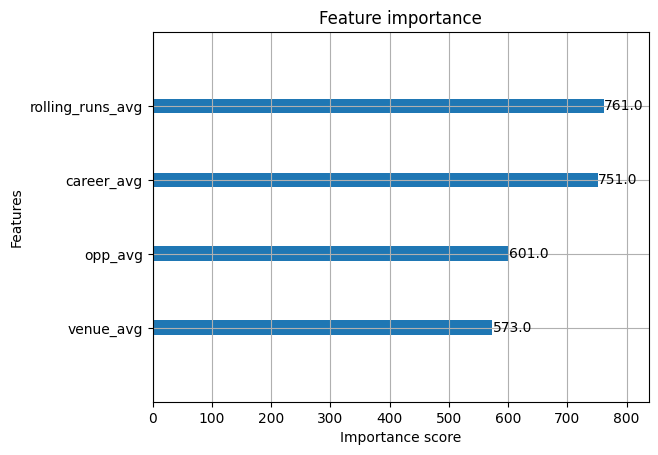

Model saved as xgb_model.joblib


In [3]:
import matplotlib.pyplot as plt

# Simple Feature Importance
xgb.plot_importance(model)
plt.show()

# Save the model artifact
joblib.dump(model, 'xgb_model.joblib')
print("Model saved as xgb_model.joblib")

In [4]:
from sklearn.model_selection import GridSearchCV

# Define the grid of parameters to test
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid,
                           cv=3, scoring='neg_mean_absolute_error', verbose=1)

# Fit the grid search
print("Starting Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Final Save of the optimized model
joblib.dump(best_model, 'xgb_model_optimized.joblib')

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


['xgb_model_optimized.joblib']